In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

(32, 32, 3)


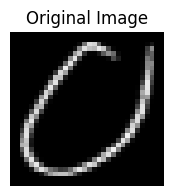

In [22]:
file0 = 'C:/Coding space/Image and Video Processing/project/GROUP10/train/0/4558.png'
img0 = cv2.imread(file0)
print(img0.shape)

plt.figure(figsize=(2,2))
plt.imshow(img0, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [23]:
# Data splits 

check_trining_reached_dict = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}

train_pd = pd.read_csv('C:/Coding space/Image and Video Processing/project/GROUP10/train.csv')
trainsize = int(train_pd.shape[0] * 0.7)

labels_list = []
images_list = []

# We randomly select "trainsize" number of images from the train csv and train model
for i in range(trainsize):
    j = random.randint(0, len(train_pd)-1)

    label = train_pd.iloc[j]['Category']

    if check_trining_reached_dict[label] < 40:
        file = 'C:/Coding space/Image and Video Processing/project/GROUP10/train/{}/{}.png'.format(
            label, train_pd.iloc[j]['Id'])
        
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

        labels_list.append(label)
        images_list.append(img)



# print(check_trining_reached_dict)
print('Total number of images selected for training: {}'.format(len(labels_list)))

X = np.array(images_list)
y = np.array(labels_list)

X = X.reshape(X.shape[0], -1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print ('Training set size: {}'.format(X_train.shape[0]))
print ('Validation set size: {}'.format(X_val.shape[0]))

Total number of images selected for training: 11900
Training set size: 9520
Validation set size: 2380


In [24]:
# Knn Classifier with just one neighbour for a quick test

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# test here with 10 random images from the test set
predictions = knn.predict(X_val)
accuracy = accuracy_score(y_val, predictions)

print(f"Internal Validation Accuracy: {accuracy * 100:.2f}%")

# --- TEST WITH 10 RANDOM SAMPLES FROM THE VAL SET ---
print("\n--- Quick Sample Check ---")
for i in range(10):
    idx = random.randint(0, len(X_val) - 1)
    pred = knn.predict(X_val[idx].reshape(1, -1))[0]
    actual = y_val[idx]
    
    status = "Success !!!" if pred == actual else "Failed !!!"
    print(f"Sample {i+1}: Actual={actual}, Predicted={pred} {status}")

Internal Validation Accuracy: 97.65%

--- Quick Sample Check ---
Sample 1: Actual=9, Predicted=9 Success !!!
Sample 2: Actual=6, Predicted=6 Success !!!
Sample 3: Actual=9, Predicted=9 Success !!!
Sample 4: Actual=6, Predicted=6 Success !!!
Sample 5: Actual=8, Predicted=8 Success !!!
Sample 6: Actual=9, Predicted=9 Success !!!
Sample 7: Actual=3, Predicted=3 Success !!!
Sample 8: Actual=4, Predicted=4 Success !!!
Sample 9: Actual=0, Predicted=0 Success !!!
Sample 10: Actual=0, Predicted=0 Success !!!


In [29]:
# Random Forest implementations 

list_of_n_estimators = [1, 10, 50, 100, 1000]

for n in list_of_n_estimators:
    rf_model = RandomForestClassifier(n_estimators = n)

    rf_model.fit(X_train, y_train)

    rf_predictions = rf_model.predict(X_val)
    rf_accuracy = accuracy_score(y_val, rf_predictions)

    print(f"Random Forest Accuracy with {n} trees: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy with 1 trees: 84.29%
Random Forest Accuracy with 10 trees: 96.72%
Random Forest Accuracy with 50 trees: 97.94%
Random Forest Accuracy with 100 trees: 98.19%
Random Forest Accuracy with 1000 trees: 98.24%


In [30]:
test_pd = pd.read_csv('C:/Coding space/Image and Video Processing/project/GROUP10/test.csv')

test_images_list = []
for i in range(len(test_pd)):
    file = 'C:/Coding space/Image and Video Processing/project/GROUP10/test/{}.png'.format(test_pd.iloc[i]['Id'])
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
    test_images_list.append(img)
    
X_test_raw = np.array(test_images_list)
print(X_test_raw.shape)

(3000, 32, 32)


In [ ]:
y_test_predicted = [rf_model.predict(X_test_raw[i].reshape(1, -1))[0] for i in range(X_test_raw.shape[0])]

submission = pd.DataFrame({"Id": test_pd["Id"], "Category": y_test_predicted})
submission.to_csv("submission_nikhil_trying.csv", index=False)